In [1]:
!pip install -q lpips
!pip install -q clean-fid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.8 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.utils import save_image
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import time
import pprint
from tqdm import tqdm
from functools import partial

import lpips
import os
import shutil
from cleanfid import fid

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
!nvidia-smi

Sat May  2 18:59:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   39C    P8             13W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
def plot_training_results(train_losses, val_losses, eval_interval, title, y_title):
    plt.figure(figsize=(6, 4))

    # Map to real global steps
    steps = (np.arange(len(train_losses))) * eval_interval

    plt.plot(steps, train_losses, label='Train', alpha=0.5)
    plt.plot(steps, val_losses, label='Val')

    plt.title(title)
    plt.xlabel('Global Steps')
    plt.ylabel(y_title)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [7]:
def plot_generated_vs_original(
    model, loader, device, n=10, top_only=False, bottom_only=False
):
    originals = []
    reconstructed = []
    top_reconstructed = []
    bottom_reconstructed = []

    model.eval()

    with torch.no_grad():
        for x, _ in loader:
            batch_needed = n - sum(t.shape[0] for t in originals)
            x_batch = x[:batch_needed]

            originals.append(x_batch)

            # Full reconstruction
            reconst, _, _, _, _, _, _ = model(x_batch.to(device))
            reconstructed.append(reconst.cpu())

            # Top-only
            if top_only:
                top_reconst = reconstruct_from_top(model, x_batch, device)
                top_reconstructed.append(top_reconst)

            # Bottom-only
            if bottom_only:
                bottom_reconst = reconstruct_from_bottom(model, x_batch, device)
                bottom_reconstructed.append(bottom_reconst)

            if sum(t.shape[0] for t in originals) >= n:
                break

    originals = torch.cat(originals, dim=0)
    reconstructed = torch.cat(reconstructed, dim=0)

    rows = 2
    if top_only:
        top_reconstructed = torch.cat(top_reconstructed, dim=0)
        rows += 1
    if bottom_only:
        bottom_reconstructed = torch.cat(bottom_reconstructed, dim=0)
        rows += 1

    fig, axes = plt.subplots(rows, n, figsize=(2*n, 2*rows))

    row_idx = 0

    # Row 1: Original
    for i in range(n):
        axes[row_idx, i].imshow(torch.permute(originals[i], (1, 2, 0)))
        axes[row_idx, i].axis("off")
        if i == 0:
            axes[row_idx, i].set_title("Original", loc="left", fontsize=10)
    row_idx += 1

    # Row 2: Full reconstruction
    for i in range(n):
        axes[row_idx, i].imshow(torch.permute(reconstructed[i], (1, 2, 0)))
        axes[row_idx, i].axis("off")
        if i == 0:
            axes[row_idx, i].set_title("Reconstructed", loc="left", fontsize=10)
    row_idx += 1

    # Row 3: Top-only
    if top_only:
        for i in range(n):
            axes[row_idx, i].imshow(torch.permute(top_reconstructed[i], (1, 2, 0)))
            axes[row_idx, i].axis("off")
            if i == 0:
                axes[row_idx, i].set_title("Top Codebook Only", loc="left", fontsize=10)
        row_idx += 1

    # Row 4: Bottom-only
    if bottom_only:
        for i in range(n):
            axes[row_idx, i].imshow(torch.permute(bottom_reconstructed[i], (1, 2, 0)))
            axes[row_idx, i].axis("off")
            if i == 0:
                axes[row_idx, i].set_title("Bottom Codebook Only", loc="left", fontsize=10)

    plt.tight_layout()
    plt.show()

    model.train()

In [8]:
def evaluate_lpips(model, val_loader, device):
    loss_fn = lpips.LPIPS(net='alex').to(device)
    loss_fn.eval()

    total = 0.0
    n = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            x_recon = model(x)[0]

            # LPIPS expects [-1, 1]
            x_scaled      = x * 2 - 1
            x_recon_scaled = x_recon * 2 - 1

            total += loss_fn(x_scaled, x_recon_scaled).mean().item()
            n += 1

    return total / n


def evaluate_rfid(model, val_loader, device, n_images=5000, tmp_dir="/tmp/rfid_eval"):
    real_dir  = os.path.join(tmp_dir, "real")
    recon_dir = os.path.join(tmp_dir, "recon")

    # clean slate
    if os.path.exists(tmp_dir):
        shutil.rmtree(tmp_dir)
    os.makedirs(real_dir)
    os.makedirs(recon_dir)

    model.eval()
    idx = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            x_recon = model(x)[0]

            for i in range(x.size(0)):
                save_image(x[i],       os.path.join(real_dir,  f"{idx}.png"))
                save_image(x_recon[i], os.path.join(recon_dir, f"{idx}.png"))
                idx += 1
                if idx >= n_images:
                    break
            if idx >= n_images:
                break

    score = fid.compute_fid(real_dir, recon_dir)
    shutil.rmtree(tmp_dir)  # cleanup
    return score

gen_eval = {}

# **Imagenette**

## **Dataset Loading (Imagenette)**

In [9]:
transform = transforms.Compose([
    transforms.Resize(270),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
])

train_dataset = datasets.Imagenette(
    root="/content/drive/My Drive/GenAI/Data",
    split="train",
    size="full",
    download=True,
    transform=transform
)

val_dataset = datasets.Imagenette(
    root="/content/drive/My Drive/GenAI/Data",
    split="val",
    size="full",
    download=True,
    transform=transform
)

In [10]:
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(val_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

Train size: 9469
Test size: 3925
Image shape: torch.Size([3, 256, 256])


In [11]:
train_dataset[0][0].max(), train_dataset[0][0].min(), train_dataset[0][0].unique().numel()

(tensor(1.), tensor(0.0902), 233)

In [12]:
train_dataset.class_to_idx

{'tench': 0,
 'Tinca tinca': 0,
 'English springer': 1,
 'English springer spaniel': 1,
 'cassette player': 2,
 'chain saw': 3,
 'chainsaw': 3,
 'church': 4,
 'church building': 4,
 'French horn': 5,
 'horn': 5,
 'garbage truck': 6,
 'dustcart': 6,
 'gas pump': 7,
 'gasoline pump': 7,
 'petrol pump': 7,
 'island dispenser': 7,
 'golf ball': 8,
 'parachute': 9,
 'chute': 9}

In [13]:
idx_to_class = {v:k for k,v in train_dataset.class_to_idx.items()}

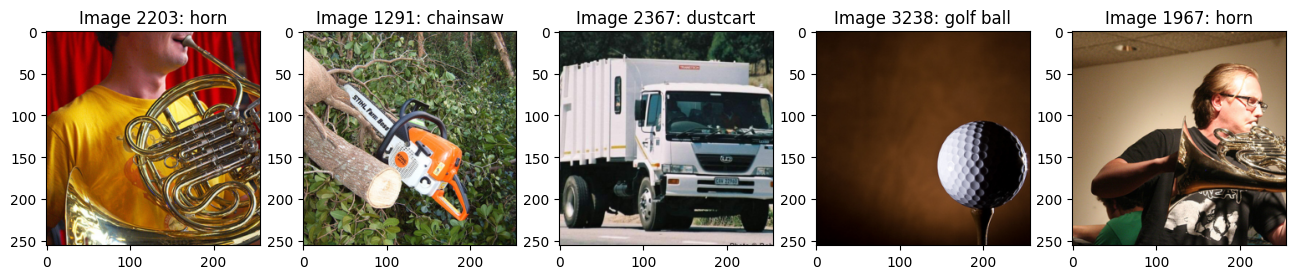

In [14]:
np.random.seed(123)

random_indices = np.random.choice(len(val_dataset), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 8))

for ax,i in zip(axes, random_indices):
  ax.imshow(torch.permute(val_dataset[i][0], (1,2,0)))
  ax.set_title(f"Image {i}: {idx_to_class[val_dataset[i][1]]}")

plt.show()

In [15]:
samples = torch.stack([val_dataset[i][0] for i in random_indices], dim=0)
labels = torch.stack([torch.tensor(val_dataset[i][1]) for i in random_indices], dim=0)

## **VQVAE2 (Hierarchical Codebooks)**

In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, res_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(in_channels, res_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(res_channels, in_channels, 1),
        )

    def forward(self, x):
        return x + self.block(x)

class Encoder(nn.Module):
  def __init__(self, in_channels, hidden_channels, res_channels, factor):
    super().__init__()
    if factor==4:
      self.net = nn.Sequential(
          nn.Conv2d(in_channels, hidden_channels//2, 4, stride=2, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(hidden_channels//2, hidden_channels, 4, stride=2, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(hidden_channels, hidden_channels, 3, padding=1),
          ResidualBlock(hidden_channels, res_channels),
          ResidualBlock(hidden_channels, res_channels),
          nn.ReLU(inplace=True)
      )
    elif factor==2:
      self.net = nn.Sequential(
          nn.Conv2d(in_channels, hidden_channels//2, 4, stride=2, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(hidden_channels//2, hidden_channels, 3, padding=1),
          ResidualBlock(hidden_channels, res_channels),
          ResidualBlock(hidden_channels, res_channels),
          nn.ReLU(inplace=True)
      )

  def forward(self, x):
    return self.net(x)

class Decoder(nn.Module):
  def __init__(self, in_channels, hidden_channels, out_channels, res_channels, factor):
    super().__init__()
    if factor==4:
      self.net = nn.Sequential(
          nn.Conv2d(in_channels, hidden_channels, 3, padding=1),
          ResidualBlock(hidden_channels, res_channels),
          ResidualBlock(hidden_channels, res_channels),
          nn.ReLU(inplace=True),
          nn.ConvTranspose2d(hidden_channels, hidden_channels//2, 4, stride=2, padding=1),
          nn.ConvTranspose2d(hidden_channels//2, out_channels, 4, stride=2, padding=1)
      )
    elif factor==2:
      self.net = nn.Sequential(
          nn.Conv2d(in_channels, hidden_channels, 3, padding=1),
          ResidualBlock(hidden_channels, res_channels),
          ResidualBlock(hidden_channels, res_channels),
          nn.ReLU(inplace=True),
          nn.ConvTranspose2d(hidden_channels, out_channels, 4, stride=2, padding=1)
      )

  def forward(self, x):
    return self.net(x)

In [18]:
class VQ(nn.Module):
  def __init__(self, latent_dim, k, normalize_codebook, decay=0.99): # k = number of discrete vectors or size of codebook
    super().__init__()
    self.k = k
    self.latent_dim = latent_dim
    self.normalize_codebook = normalize_codebook
    self.register_buffer("moving_sum", torch.zeros(k, latent_dim))
    self.register_buffer("moving_count", torch.zeros(k))
    self.register_buffer("codebook", torch.zeros(k, latent_dim))
    self.register_buffer("initialized", torch.tensor(False))
    self.register_buffer("decay", torch.tensor(decay))

  def forward(self, z_e, training):
    B, C, H, W = z_e.shape
    ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
    if not self.initialized:
      ze_flatten = ze_permute.reshape(-1, C)
      if ze_flatten.shape[0] < self.k:
        indices = torch.randint(0, ze_flatten.shape[0], (self.k,))
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)
      else:
        indices = torch.randperm(ze_flatten.shape[0])[:self.k]
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)

    if self.normalize_codebook:
      ze_norm = F.normalize(ze_permute, dim=-1)          # (B, H, W, C)
      codebook_norm = F.normalize(self.codebook, dim=-1) # (k, C)

      # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
      cross = ze_norm @ codebook_norm.T # (B, H, W, k)
      z_l2_sq = (ze_norm ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
      e_l2_sq = (codebook_norm ** 2).sum(dim=-1) # (k,)

      discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
      z_q = codebook_norm[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)
    else:
      # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
      cross = ze_permute @ self.codebook.T # (B, H, W, k)
      z_l2_sq = (ze_permute ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
      e_l2_sq = (self.codebook ** 2).sum(dim=-1) # (k,)

      discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
      z_q = self.codebook[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)

    # EMA codebook update
    if training:
      n_t = torch.zeros(self.k, device=z_e.device)
      codes_flatten = discrete_codes.reshape(-1)
      n_t.scatter_add_(0, codes_flatten, torch.ones(codes_flatten.shape, device=z_e.device)) # current code-wise utilization count
      self.moving_count.copy_(self.moving_count * self.decay + n_t * (1 - self.decay))
      ze_flatten = ze_permute.reshape(-1, C)
      current_code_sum = torch.zeros_like(self.moving_sum)
      # for i in range(self.k):
      #   assigned_indices = torch.where(codes_flatten == i)[0]
      #   if assigned_indices.shape[0] > 0:
      #     assigned_ze = ze_flatten[assigned_indices]
      #     m_i = assigned_ze.sum(0)
      #     current_code_sum[i] = m_i
      current_code_sum.scatter_add_(0, codes_flatten.unsqueeze(-1).expand(-1, C), ze_flatten)
      self.moving_sum.copy_(self.moving_sum * self.decay + current_code_sum * (1 - self.decay))
      safe_count = self.moving_count.unsqueeze(-1).clamp(min=1e-6)
      self.codebook.data.copy_(self.moving_sum / safe_count)
      if self.normalize_codebook:
        self.codebook.data.copy_(F.normalize(self.codebook.data, dim=-1))

    return z_q, discrete_codes

In [19]:
class VQVAE2(nn.Module):
  def __init__(self, in_channels, hidden_channels, res_channels, latent_dim, k, normalize_codebook):
    super().__init__()
    self.encoder_b = Encoder(in_channels, hidden_channels, res_channels, factor=4)
    self.encoder_t = Encoder(hidden_channels, hidden_channels, res_channels, factor=2)
    self.vq_t = VQ(latent_dim, k, normalize_codebook)
    self.conv_t = nn.Conv2d(hidden_channels, latent_dim, 1) # 128 channels -> 64 channels before quantizing top codebook
    self.decoder_t = Decoder(latent_dim, hidden_channels, latent_dim, res_channels, factor=2)
    self.conv_b = nn.Conv2d(hidden_channels + latent_dim, latent_dim, 1) # concatenated bottom encoded feature maps and partially decoded top latent (128 + 64) -> latent dim (64)
    self.vq_b = VQ(latent_dim, k, normalize_codebook)
    self.upsample_t = nn.ConvTranspose2d(latent_dim, latent_dim, 4, stride=2, padding=1)
    self.decoder = Decoder(latent_dim + latent_dim, hidden_channels, in_channels, res_channels, factor=4)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x, training=False):
    features_b = self.encoder_b(x) # (b, 128, 64, 64) considering 256 x 256 x 3 image
    features_t = self.encoder_t(features_b) # (b, 128, 32, 32)
    features_t_64 = self.conv_t(features_t) # (b, 64, 32, 32)
    z_t, codes_t = self.vq_t(features_t_64, training) # (b, 64, 32, 32), (b, 32, 32)
    inp_decoded_t = features_t_64 + (z_t - features_t_64).detach() # straight through estimator
    decoded_t = self.decoder_t(inp_decoded_t) # (b, 64, 64, 64)
    features_b_cat = torch.cat([decoded_t, features_b], dim=1) # concatenating in channel dim; (b, 192, 64, 64)
    features_b_64 = self.conv_b(features_b_cat) # (b, 64, 64, 64)
    z_b, codes_b = self.vq_b(features_b_64, training) # (b, 64, 64, 64), (b, 64, 64)
    upsampled_t = self.upsample_t(inp_decoded_t) # (b, 64, 64, 64)
    inp_decoded_b = features_b_64 + (z_b - features_b_64).detach() # straight through estimator
    reconst = self.sigmoid(self.decoder(torch.cat([upsampled_t, inp_decoded_b], dim=1))) # (b, 128, 64, 64) [concatenated] -> (b, 3, 256, 256) [output]

    return reconst, z_t, z_b, codes_t, codes_b, features_t_64, features_b_64

### Training (Reconstruction + Commitment Loss)

In [ ]:
def calc_batch_loss(model, x, device, training, beta=0.25):
  x = x.to(device)
  reconst, z_t, z_b, codes_t, codes_b, features_t_64, features_b_64 = model(x, training)
  l_1 = nn.functional.binary_cross_entropy(reconst, x)
  zt_permute = torch.permute(z_t, (0, 2, 3, 1)) # (B, H, W, C)
  ft_permute = torch.permute(features_t_64, (0, 2, 3, 1)) # (B, H, W, C)
  zb_permute = torch.permute(z_b, (0, 2, 3, 1)) # (B, H, W, C)
  fb_permute = torch.permute(features_b_64, (0, 2, 3, 1)) # (B, H, W, C)
  l_3_1 = (beta * torch.norm(ft_permute - zt_permute.detach(), dim=-1) ** 2).mean()
  l_3_2 = (beta * torch.norm(fb_permute - zb_permute.detach(), dim=-1) ** 2).mean()
  l_3 = l_3_1 + l_3_2
  loss = l_1 + l_3

  return loss, l_1, l_3_1, l_3_2, codes_t, codes_b

In [ ]:
def evaluate(loader, model, device, max_batch, k):
  total_loss = 0
  total_l1_loss, total_l3_1_loss, total_l3_2_loss = 0, 0, 0
  all_codes_t, all_codes_b = [], []
  if max_batch is None:
    max_batch = len(loader)
  elif max_batch <= 0:
    return float("nan")
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        loss, l_1, l_3_1, l_3_2, codes_t, codes_b = calc_batch_loss(model, x, device, training=False)
      total_loss += loss.item()
      total_l1_loss += l_1.item()
      total_l3_1_loss += l_3_1.item()
      total_l3_2_loss += l_3_2.item()
      all_codes_t.append(codes_t.reshape(-1))
      all_codes_b.append(codes_b.reshape(-1))
    else:
      break
  all_codes_t = torch.cat(all_codes_t, dim=0)
  all_codes_b = torch.cat(all_codes_b, dim=0)

  return total_loss/max_batch, total_l1_loss/max_batch, total_l3_1_loss/max_batch, total_l3_2_loss/max_batch, all_codes_t.unique().numel() / k, all_codes_b.unique().numel() / k

In [ ]:
def reconstruct(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      reconst, _, _, _, _, _, _ = model(x, training=False)
    return reconst.cpu()

In [ ]:
def reconstruct_from_top(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      features_b = model.encoder_b(x)
      features_t = model.encoder_t(features_b)
      features_t_64 = model.conv_t(features_t)
      z_t, codes_t = model.vq_t(features_t_64, training=False)
      print(f"Unique Top Codes: {codes_t.unique().numel()}")
      inp_decoded_t = features_t_64 + (z_t - features_t_64).detach()
      upsampled_t = model.upsample_t(inp_decoded_t)
      zeros = torch.zeros_like(upsampled_t)
      reconst = model.sigmoid(model.decoder(torch.cat([upsampled_t, zeros], dim=1)))
    return reconst.cpu()

In [ ]:
def reconstruct_from_bottom(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      features_b = model.encoder_b(x)
      features_t = model.encoder_t(features_b)
      features_t_64 = model.conv_t(features_t)
      z_t, codes_t = model.vq_t(features_t_64, training=False)
      inp_decoded_t = features_t_64 + (z_t - features_t_64).detach()
      decoded_t = model.decoder_t(inp_decoded_t)
      features_b_cat = torch.cat([decoded_t, features_b], dim=1)
      features_b_64 = model.conv_b(features_b_cat)
      z_b, codes_b = model.vq_b(features_b_64, training=False)
      print(f"Unique Top Codes: {codes_b.unique().numel()}")
      inp_decoded_b = features_b_64 + (z_b - features_b_64).detach()
      zeros = torch.zeros_like(inp_decoded_b)
      reconst = model.sigmoid(model.decoder(torch.cat([zeros, inp_decoded_b], dim=1)))
    return reconst.cpu()

In [ ]:
train_loader1 = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader1 = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

In [ ]:
len(train_loader1), len(val_loader1)

(1184, 491)

In [ ]:
def train_vqvae2(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=20,
    eval_interval=500,
    k=512,
    samples=None,
    labels=None
):

    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    global_step = -1

    # logs
    train_losses, val_losses = [], []
    train_l1_losses, val_l1_losses = [], []
    train_l3_1_losses, val_l3_1_losses = [], []
    train_l3_2_losses, val_l3_2_losses = [], []
    train_codebook_t, val_codebook_t = [], []
    train_codebook_b, val_codebook_b = [], []

    t_start = time.time()
    model.train()

    for epoch in range(epochs):
        for x, _ in train_loader:
            optimizer.zero_grad()

            loss, _, _, _, _, _ = calc_batch_loss(
                model, x, device, training=True
            )
            loss.backward()
            optimizer.step()

            global_step += 1

            if global_step % eval_interval == 0:
                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done
                eta_minutes = (elapsed / steps_done) * steps_left / 60

                model.eval()

                train_loss, train_l1, train_l3_1, train_l3_2, train_cu_t, train_cu_b = evaluate(
                    train_loader, model, device, max_batch=20, k=k
                )
                val_loss, val_l1, val_l3_1, val_l3_2, val_cu_t, val_cu_b = evaluate(
                    val_loader, model, device, max_batch=None, k=k
                )

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3_1={train_l3_1:.4f}, l3_2={train_l3_2:.4f})")
                print(f"\tCodebook T/B: {train_cu_t:.2f} / {train_cu_b:.2f}")
                print(f"\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3_1={val_l3_1:.4f}, l3_2={val_l3_2:.4f})")
                print(f"\tCodebook T/B: {val_cu_t:.2f} / {val_cu_b:.2f}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

                # store logs
                train_losses.append(train_loss)
                val_losses.append(val_loss)

                train_l1_losses.append(train_l1)
                val_l1_losses.append(val_l1)

                train_l3_1_losses.append(train_l3_1)
                val_l3_1_losses.append(val_l3_1)

                train_l3_2_losses.append(train_l3_2)
                val_l3_2_losses.append(val_l3_2)

                train_codebook_t.append(train_cu_t)
                val_codebook_t.append(val_cu_t)

                train_codebook_b.append(train_cu_b)
                val_codebook_b.append(val_cu_b)

                # reconstruction viz
                if samples is not None and labels is not None:
                    reconst = reconstruct(model, samples, device)

                    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
                    for i in range(5):
                        axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                        axes[0, i].set_title(f"orig {labels[i]}")
                        axes[0, i].axis("off")

                        axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                        axes[1, i].set_title(f"recon {labels[i]}")
                        axes[1, i].axis("off")

                    plt.tight_layout()
                    plt.show()

                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_l1": train_l1_losses,
        "val_l1": val_l1_losses,
        "train_l3_1": train_l3_1_losses,
        "val_l3_1": val_l3_1_losses,
        "train_l3_2": train_l3_2_losses,
        "val_l3_2": val_l3_2_losses,
        "train_codebook_t": train_codebook_t,
        "val_codebook_t": val_codebook_t,
        "train_codebook_b": train_codebook_b,
        "val_codebook_b": val_codebook_b,
    }

#### Exp 1

In [ ]:
torch.manual_seed(123)

model1 = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=64, k=512, normalize_codebook=True).to(device)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-4)

logs = train_vqvae2(
    model=model1,
    train_loader=train_loader1,
    val_loader=val_loader1,
    optimizer=optimizer1,
    device=device,
    epochs=4,
    eval_interval=500,
    k=512,
    samples=samples,
    labels=labels
)

In [ ]:
torch.save(model1.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae2_exp1.pt")

In [ ]:
plot_training_results(logs["train_loss"], logs["val_loss"], 500, title="Training Progress", y_title="Total Loss")

In [ ]:
plot_training_results(logs["train_l1"], logs["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

In [ ]:
plot_training_results(logs["train_l3_1"], logs["val_l3_1"], 500, title="Training Progress", y_title="Commitment Loss (Top Features)")

In [ ]:
plot_training_results(logs["train_l3_2"], logs["val_l3_2"], 500, title="Training Progress", y_title="Commitment Loss (Bottom Features)")

In [ ]:
plot_training_results(logs["train_codebook_t"], logs["val_codebook_t"], 500, title="Training Progress", y_title="Codebook Utilization (Top)")

In [ ]:
plot_training_results(logs["train_codebook_b"], logs["val_codebook_b"], 500, title="Training Progress", y_title="Codebook Utilization (Bottom)")

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=64, k=512, normalize_codebook=True)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp1.pt"))
model.to(device)
model.eval()

plot_generated_vs_original(model, val_loader1, device=device, top_only=True, bottom_only=True)

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=64, k=512, normalize_codebook=True)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp1.pt"))
model.to(device)
model.eval()

lpips_score = evaluate_lpips(model, val_loader1, device)
rfid_score  = evaluate_rfid(model, val_loader1, device, n_images=5000)

gen_eval["exp_1"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

#### Exp 2

In [ ]:
torch.manual_seed(123)

model2 = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=True).to(device)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-4)

logs2 = train_vqvae2(
    model=model2,
    train_loader=train_loader1,
    val_loader=val_loader1,
    optimizer=optimizer2,
    device=device,
    epochs=4,
    eval_interval=500,
    k=512,
    samples=samples,
    labels=labels
)

In [ ]:
torch.save(model2.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae2_exp2.pt")

In [ ]:
plot_training_results(logs2["train_loss"], logs2["val_loss"], 500, title="Training Progress", y_title="Total Loss")

In [ ]:
plot_training_results(logs2["train_l1"], logs2["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

In [ ]:
plot_training_results(logs2["train_l3_1"], logs2["val_l3_1"], 500, title="Training Progress", y_title="Commitment Loss (Top Features)")

In [ ]:
plot_training_results(logs2["train_l3_2"], logs2["val_l3_2"], 500, title="Training Progress", y_title="Commitment Loss (Bottom Features)")

In [ ]:
plot_training_results(logs2["train_codebook_t"], logs2["val_codebook_t"], 500, title="Training Progress", y_title="Codebook Utilization (Top)")

In [ ]:
plot_training_results(logs2["train_codebook_b"], logs2["val_codebook_b"], 500, title="Training Progress", y_title="Codebook Utilization (Bottom)")

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=True)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp2.pt"))
model.to(device)
model.eval()

plot_generated_vs_original(model, val_loader1, device=device, top_only=True, bottom_only=True)

top codebook is collapsing to very very few codes and doesnt encode any meaningful global information that can be seen by reconstructing image from top codes only.

however, when image was reconstructed using only bottom code only, it resulted in same image as reconstruction from bottom + top. This means top codes are not being used.

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=True)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp2.pt"))
model.to(device)
model.eval()

lpips_score = evaluate_lpips(model, val_loader1, device)
rfid_score  = evaluate_rfid(model, val_loader1, device, n_images=5000)

gen_eval["exp_2"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

#### Exp 3

In [ ]:
torch.manual_seed(123)

model3 = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=False).to(device)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=1e-4)

logs3 = train_vqvae2(
    model=model3,
    train_loader=train_loader1,
    val_loader=val_loader1,
    optimizer=optimizer3,
    device=device,
    epochs=4,
    eval_interval=500,
    k=512,
    samples=samples,
    labels=labels
)

In [ ]:
torch.save(model3.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae2_exp3.pt")

In [ ]:
plot_training_results(logs3["train_loss"], logs3["val_loss"], 500, title="Training Progress", y_title="Total Loss")

In [ ]:
plot_training_results(logs3["train_l1"], logs3["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

In [ ]:
plot_training_results(logs3["train_l3_1"], logs3["val_l3_1"], 500, title="Training Progress", y_title="Commitment Loss (Top Features)")

In [ ]:
plot_training_results(logs3["train_l3_2"], logs3["val_l3_2"], 500, title="Training Progress", y_title="Commitment Loss (Bottom Features)")

In [ ]:
plot_training_results(logs3["train_codebook_t"], logs3["val_codebook_t"], 500, title="Training Progress", y_title="Codebook Utilization (Top)")

In [ ]:
plot_training_results(logs3["train_codebook_b"], logs3["val_codebook_b"], 500, title="Training Progress", y_title="Codebook Utilization (Bottom)")

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=False)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp3.pt"))
model.to(device)
model.eval()

plot_generated_vs_original(model, val_loader1, device=device, top_only=True, bottom_only=True)

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=False)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp3.pt"))
model.to(device)
model.eval()

lpips_score = evaluate_lpips(model, val_loader1, device)
rfid_score  = evaluate_rfid(model, val_loader1, device, n_images=5000)

gen_eval["exp_3"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

#### Exp 4

In [ ]:
torch.manual_seed(123)

model4 = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=64, k=512, normalize_codebook=False).to(device)
optimizer4 = torch.optim.Adam(model4.parameters(), lr=1e-4)

logs4 = train_vqvae2(
    model=model4,
    train_loader=train_loader1,
    val_loader=val_loader1,
    optimizer=optimizer4,
    device=device,
    epochs=4,
    eval_interval=500,
    k=512,
    samples=samples,
    labels=labels
)

In [ ]:
torch.save(model4.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae2_exp4.pt")

In [ ]:
plot_training_results(logs4["train_loss"], logs4["val_loss"], 500, title="Training Progress", y_title="Total Loss")

In [ ]:
plot_training_results(logs4["train_l1"], logs4["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

In [ ]:
plot_training_results(logs4["train_l3_1"], logs4["val_l3_1"], 500, title="Training Progress", y_title="Commitment Loss (Top Features)")

In [ ]:
plot_training_results(logs4["train_l3_2"], logs4["val_l3_2"], 500, title="Training Progress", y_title="Commitment Loss (Bottom Features)")

In [ ]:
plot_training_results(logs4["train_codebook_t"], logs4["val_codebook_t"], 500, title="Training Progress", y_title="Codebook Utilization (Top)")

In [ ]:
plot_training_results(logs4["train_codebook_b"], logs4["val_codebook_b"], 500, title="Training Progress", y_title="Codebook Utilization (Bottom)")

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=64, k=512, normalize_codebook=False)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp4.pt"))
model.to(device)
model.eval()

plot_generated_vs_original(model, val_loader1, device=device, top_only=True, bottom_only=True)

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=64, k=512, normalize_codebook=False)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp4.pt"))
model.to(device)
model.eval()

lpips_score = evaluate_lpips(model, val_loader1, device)
rfid_score  = evaluate_rfid(model, val_loader1, device, n_images=5000)

gen_eval["exp_4"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

### Training (Reconstruction + Perceptual + Commitment Loss)

In [20]:
def calc_batch_loss2(model, x, device, training, percep_loss_fn, lambda_=0.1, beta=0.25):
  x = x.to(device)
  reconst, z_t, z_b, codes_t, codes_b, features_t_64, features_b_64 = model(x, training)
  l_1 = nn.functional.binary_cross_entropy(reconst, x)
  x_scaled = x * 2 - 1
  reconst_scaled = reconst * 2 - 1
  percep_loss = percep_loss_fn(x_scaled, reconst_scaled).mean()
  zt_permute = torch.permute(z_t, (0, 2, 3, 1)) # (B, H, W, C)
  ft_permute = torch.permute(features_t_64, (0, 2, 3, 1)) # (B, H, W, C)
  zb_permute = torch.permute(z_b, (0, 2, 3, 1)) # (B, H, W, C)
  fb_permute = torch.permute(features_b_64, (0, 2, 3, 1)) # (B, H, W, C)
  l_3_1 = (beta * torch.norm(ft_permute - zt_permute.detach(), dim=-1) ** 2).mean()
  l_3_2 = (beta * torch.norm(fb_permute - zb_permute.detach(), dim=-1) ** 2).mean()
  l_3 = l_3_1 + l_3_2
  loss = l_1 + l_3 + percep_loss

  return loss, l_1, l_3_1, l_3_2, percep_loss, codes_t, codes_b

In [21]:
def evaluate2(loader, model, device, percep_loss_fn, max_batch, k, lambda_=0.1):
  total_loss = 0
  total_l1_loss, total_l3_1_loss, total_l3_2_loss, total_percep_loss = 0, 0, 0, 0
  all_codes_t, all_codes_b = [], []
  if max_batch is None:
    max_batch = len(loader)
  elif max_batch <= 0:
    return float("nan")
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        loss, l_1, l_3_1, l_3_2, percep_loss, codes_t, codes_b = calc_batch_loss2(model, x, device, training=False, percep_loss_fn=percep_loss_fn, lambda_=lambda_,)
      total_loss += loss.item()
      total_l1_loss += l_1.item()
      total_l3_1_loss += l_3_1.item()
      total_l3_2_loss += l_3_2.item()
      total_percep_loss += percep_loss.item()
      all_codes_t.append(codes_t.reshape(-1))
      all_codes_b.append(codes_b.reshape(-1))
    else:
      break
  all_codes_t = torch.cat(all_codes_t, dim=0)
  all_codes_b = torch.cat(all_codes_b, dim=0)

  return total_loss/max_batch, total_l1_loss/max_batch, total_l3_1_loss/max_batch, total_l3_2_loss/max_batch, total_percep_loss/max_batch, all_codes_t.unique().numel() / k, all_codes_b.unique().numel() / k

In [22]:
def reconstruct2(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      reconst, _, _, _, _, _, _ = model(x, training=False)
    return reconst.cpu()

In [23]:
def reconstruct_from_top(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      features_b = model.encoder_b(x)
      features_t = model.encoder_t(features_b)
      features_t_64 = model.conv_t(features_t)
      z_t, codes_t = model.vq_t(features_t_64, training=False)
      print(f"Unique Top Codes: {codes_t.unique().numel()}")
      inp_decoded_t = features_t_64 + (z_t - features_t_64).detach()
      upsampled_t = model.upsample_t(inp_decoded_t)
      zeros = torch.zeros_like(upsampled_t)
      reconst = model.sigmoid(model.decoder(torch.cat([upsampled_t, zeros], dim=1)))
    return reconst.cpu()

In [24]:
def reconstruct_from_bottom(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      features_b = model.encoder_b(x)
      features_t = model.encoder_t(features_b)
      features_t_64 = model.conv_t(features_t)
      z_t, codes_t = model.vq_t(features_t_64, training=False)
      inp_decoded_t = features_t_64 + (z_t - features_t_64).detach()
      decoded_t = model.decoder_t(inp_decoded_t)
      features_b_cat = torch.cat([decoded_t, features_b], dim=1)
      features_b_64 = model.conv_b(features_b_cat)
      z_b, codes_b = model.vq_b(features_b_64, training=False)
      print(f"Unique Top Codes: {codes_b.unique().numel()}")
      inp_decoded_b = features_b_64 + (z_b - features_b_64).detach()
      zeros = torch.zeros_like(inp_decoded_b)
      reconst = model.sigmoid(model.decoder(torch.cat([zeros, inp_decoded_b], dim=1)))
    return reconst.cpu()

In [25]:
train_loader2 = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader2 = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

In [26]:
len(train_loader2), len(val_loader2)

(1184, 491)

In [27]:
def train_vqvae2_2(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    percep_loss_fn,
    lambda_=0.1,
    epochs=20,
    eval_interval=500,
    k=512,
    samples=None,
    labels=None
):
    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    global_step = -1

    # logs
    train_losses, val_losses = [], []
    train_l1_losses, val_l1_losses = [], []
    train_l3_1_losses, val_l3_1_losses = [], []
    train_l3_2_losses, val_l3_2_losses = [], []
    train_percep_losses, val_percep_losses = [], []
    train_codebook_t, val_codebook_t = [], []
    train_codebook_b, val_codebook_b = [], []

    t_start = time.time()
    model.train()

    for epoch in range(epochs):
        for x, _ in train_loader:
            optimizer.zero_grad()

            loss, _, _, _, _, _, _ = calc_batch_loss2(
                model, x, device, training=True, percep_loss_fn=percep_loss_fn, lambda_=lambda_
            )
            loss.backward()
            optimizer.step()

            global_step += 1

            if global_step % eval_interval == 0:
                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done
                eta_minutes = (elapsed / steps_done) * steps_left / 60

                model.eval()

                train_loss, train_l1, train_l3_1, train_l3_2, train_percep_loss, train_cu_t, train_cu_b = evaluate2(
                    train_loader, model, device, percep_loss_fn, max_batch=20, k=k, lambda_=lambda_
                )
                val_loss, val_l1, val_l3_1, val_l3_2, val_percep_loss, val_cu_t, val_cu_b = evaluate2(
                    val_loader, model, device, percep_loss_fn, max_batch=None, k=k, lambda_=lambda_
                )

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3_1={train_l3_1:.4f}, l3_2={train_l3_2:.4f}, percep_loss={train_percep_loss:.4f})")
                print(f"\tCodebook T/B: {train_cu_t:.2f} / {train_cu_b:.2f}")
                print(f"\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3_1={val_l3_1:.4f}, l3_2={val_l3_2:.4f}, percep_loss={val_percep_loss:.4f})")
                print(f"\tCodebook T/B: {val_cu_t:.2f} / {val_cu_b:.2f}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

                # store logs
                train_losses.append(train_loss)
                val_losses.append(val_loss)

                train_l1_losses.append(train_l1)
                val_l1_losses.append(val_l1)

                train_l3_1_losses.append(train_l3_1)
                val_l3_1_losses.append(val_l3_1)

                train_l3_2_losses.append(train_l3_2)
                val_l3_2_losses.append(val_l3_2)

                train_percep_losses.append(train_percep_loss)
                val_percep_losses.append(val_percep_loss)

                train_codebook_t.append(train_cu_t)
                val_codebook_t.append(val_cu_t)

                train_codebook_b.append(train_cu_b)
                val_codebook_b.append(val_cu_b)

                # reconstruction viz
                if samples is not None and labels is not None:
                    reconst = reconstruct2(model, samples, device)

                    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
                    for i in range(5):
                        axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                        axes[0, i].set_title(f"orig {labels[i]}")
                        axes[0, i].axis("off")

                        axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                        axes[1, i].set_title(f"recon {labels[i]}")
                        axes[1, i].axis("off")

                    plt.tight_layout()
                    plt.show()

                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_l1": train_l1_losses,
        "val_l1": val_l1_losses,
        "train_l3_1": train_l3_1_losses,
        "val_l3_1": val_l3_1_losses,
        "train_l3_2": train_l3_2_losses,
        "val_l3_2": val_l3_2_losses,
        "train_percep_loss": train_percep_losses,
        "val_percep_loss": val_percep_losses,
        "train_codebook_t": train_codebook_t,
        "val_codebook_t": val_codebook_t,
        "train_codebook_b": train_codebook_b,
        "val_codebook_b": val_codebook_b,
    }

#### Exp 5

In [ ]:
torch.manual_seed(123)

lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()
model5 = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=False).to(device)
optimizer5 = torch.optim.Adam(model5.parameters(), lr=1e-4)

logs5 = train_vqvae2_2(
    model=model5,
    train_loader=train_loader2,
    val_loader=val_loader2,
    optimizer=optimizer5,
    device=device,
    percep_loss_fn=lpips_model,
    lambda_=0.1,
    epochs=4,
    eval_interval=500,
    k=512,
    samples=samples,
    labels=labels
)

In [ ]:
torch.save(model5.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae2_exp5.pt")

In [ ]:
plot_training_results(logs5["train_loss"], logs5["val_loss"], 500, title="Training Progress", y_title="Total Loss")

In [ ]:
plot_training_results(logs5["train_l1"], logs5["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

In [ ]:
plot_training_results(logs5["train_l3_1"], logs5["val_l3_1"], 500, title="Training Progress", y_title="Commitment Loss (Top Features)")

In [ ]:
plot_training_results(logs5["train_l3_2"], logs5["val_l3_2"], 500, title="Training Progress", y_title="Commitment Loss (Bottom Features)")

In [ ]:
plot_training_results(logs5["train_percep_loss"], logs5["val_percep_loss"], 500, title="Training Progress", y_title="Perceptual Loss")

In [ ]:
plot_training_results(logs5["train_codebook_t"], logs5["val_codebook_t"], 500, title="Training Progress", y_title="Codebook Utilization (Top)")

In [ ]:
plot_training_results(logs5["train_codebook_b"], logs5["val_codebook_b"], 500, title="Training Progress", y_title="Codebook Utilization (Bottom)")

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=False)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp5.pt"))
model.to(device)
model.eval()

plot_generated_vs_original(model, val_loader2, device=device, top_only=True, bottom_only=True)

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=False)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp5.pt"))
model.to(device)
model.eval()

lpips_score = evaluate_lpips(model, val_loader2, device)
rfid_score  = evaluate_rfid(model, val_loader2, device, n_images=5000)

gen_eval["exp_5"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

#### Exp 6

In [ ]:
torch.manual_seed(123)

lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()
model6 = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=False).to(device)
optimizer6 = torch.optim.Adam(model6.parameters(), lr=1e-4)

logs6 = train_vqvae2_2(
    model=model6,
    train_loader=train_loader2,
    val_loader=val_loader2,
    optimizer=optimizer6,
    device=device,
    percep_loss_fn=lpips_model,
    lambda_=1,
    epochs=4,
    eval_interval=500,
    k=512,
    samples=samples,
    labels=labels
)

In [ ]:
torch.save(model6.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae2_exp6.pt")

In [ ]:
plot_training_results(logs6["train_loss"], logs6["val_loss"], 500, title="Training Progress", y_title="Total Loss")

In [ ]:
plot_training_results(logs6["train_l1"], logs6["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

In [ ]:
plot_training_results(logs6["train_l3_1"], logs6["val_l3_1"], 500, title="Training Progress", y_title="Commitment Loss (Top Features)")

In [ ]:
plot_training_results(logs6["train_l3_2"], logs6["val_l3_2"], 500, title="Training Progress", y_title="Commitment Loss (Bottom Features)")

In [ ]:
plot_training_results(logs6["train_percep_loss"], logs6["val_percep_loss"], 500, title="Training Progress", y_title="Perceptual Loss")

In [ ]:
plot_training_results(logs6["train_codebook_t"], logs6["val_codebook_t"], 500, title="Training Progress", y_title="Codebook Utilization (Top)")

In [ ]:
plot_training_results(logs6["train_codebook_b"], logs6["val_codebook_b"], 500, title="Training Progress", y_title="Codebook Utilization (Bottom)")

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=False)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp6.pt"))
model.to(device)
model.eval()

plot_generated_vs_original(model, val_loader2, device=device, top_only=True, bottom_only=True)

In [28]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=8, k=512, normalize_codebook=False)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp6.pt"))
model.to(device)
model.eval()

lpips_score = evaluate_lpips(model, val_loader2, device)
rfid_score  = evaluate_rfid(model, val_loader2, device, n_images=5000)

gen_eval["exp_6"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 243MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
compute FID between two folders
Found 3925 images in the folder /tmp/rfid_eval/real


FID real : 100%|██████████| 123/123 [00:11<00:00, 10.56it/s]


Found 3925 images in the folder /tmp/rfid_eval/recon


FID recon : 100%|██████████| 123/123 [00:11<00:00, 10.97it/s]


LPIPS: 0.0974
rFID:  34.52


#### Exp 7

In [ ]:
torch.manual_seed(123)

lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()
model7 = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=64, k=512, normalize_codebook=True).to(device)
optimizer7 = torch.optim.Adam(model7.parameters(), lr=1e-4)

logs7 = train_vqvae2_2(
    model=model7,
    train_loader=train_loader2,
    val_loader=val_loader2,
    optimizer=optimizer7,
    device=device,
    percep_loss_fn=lpips_model,
    lambda_=0.1,
    epochs=4,
    eval_interval=500,
    k=512,
    samples=samples,
    labels=labels
)

In [30]:
torch.save(model7.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae2_exp7.pt")

In [ ]:
plot_training_results(logs7["train_loss"], logs7["val_loss"], 500, title="Training Progress", y_title="Total Loss")

In [ ]:
plot_training_results(logs7["train_l1"], logs7["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

In [ ]:
plot_training_results(logs7["train_l3_1"], logs7["val_l3_1"], 500, title="Training Progress", y_title="Commitment Loss (Top Features)")

In [ ]:
plot_training_results(logs7["train_l3_2"], logs7["val_l3_2"], 500, title="Training Progress", y_title="Commitment Loss (Bottom Features)")

In [ ]:
plot_training_results(logs7["train_percep_loss"], logs7["val_percep_loss"], 500, title="Training Progress", y_title="Perceptual Loss")

In [ ]:
plot_training_results(logs7["train_codebook_t"], logs7["val_codebook_t"], 500, title="Training Progress", y_title="Codebook Utilization (Top)")

In [ ]:
plot_training_results(logs7["train_codebook_b"], logs7["val_codebook_b"], 500, title="Training Progress", y_title="Codebook Utilization (Bottom)")

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=64, k=512, normalize_codebook=True)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp7.pt"))
model.to(device)
model.eval()

plot_generated_vs_original(model, val_loader2, device=device, top_only=True, bottom_only=True)

In [ ]:
model = VQVAE2(in_channels=3, hidden_channels=128, res_channels=64, latent_dim=64, k=512, normalize_codebook=True)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae2_exp7.pt"))
model.to(device)
model.eval()

lpips_score = evaluate_lpips(model, val_loader2, device)
rfid_score  = evaluate_rfid(model, val_loader2, device, n_images=5000)

gen_eval["exp_7"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")